In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

ROUTE = "B41"
YEAR = 2017
TRAIN_MONTH = [6, 10]
VAL_MONTH = 8
TEST_MONTH = 12

In [69]:
bus = pd.read_csv("nyc_bus_cleaned.csv")

bus["RecordedAtTime"] = pd.to_datetime(bus["RecordedAtTime"], errors="coerce")
bus["Scheduled_dt"] = pd.to_datetime(bus["Scheduled_dt"], errors="coerce")
bus["ExpectedArrivalTime"] = pd.to_datetime(bus["ExpectedArrivalTime"], errors="coerce")

bus = bus[
    (bus["PublishedLineName"] == ROUTE) &
    (bus["Scheduled_dt"].dt.year == YEAR) &
    (bus["Scheduled_dt"].dt.month.isin(TRAIN_MONTH + [VAL_MONTH]))
].copy()

print(f"Loaded rows: {len(bus):,}")
print(f"Date range: {bus['Scheduled_dt'].min()} to {bus['Scheduled_dt'].max()}")
display(bus.head(3))

Loaded rows: 266,081
Date range: 2017-06-01 00:00:00 to 2017-10-31 23:59:02


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,Scheduled_dt,delay_minutes
388,2017-06-01 00:03:31,1.0,B41,CADMAN PLAZA WEST/JOHNSON ST,40.695534,-73.990829,KINGS PLAZA via FLATBSH,40.609211,-73.921516,NYCT_4602,40.649097,-73.958392,FLATBUSH AV/ALBEMARLE RD,< 1 stop away,215.0,2017-06-01 00:04:41,00:05:22,2017-06-01 00:05:22,-0.683333
439,2017-06-01 00:03:42,0.0,B41,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,DNTWN BKLYN CADMAN PLZ via FLATBSH,40.695408,-73.990784,NYCT_4621,40.692423,-73.990166,JORALEMON ST/COURT ST,approaching,46.0,2017-06-01 00:03:57,00:03:31,2017-06-01 00:03:31,0.433333
622,2017-06-01 00:03:36,0.0,B41,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,DNTWN BKLYN CADMAN PLZ via FLATBSH,40.695408,-73.990784,NYCT_4595,40.632267,-73.947073,FLATBUSH AV/NOSTRAND AV,approaching,68.0,2017-06-01 00:03:56,00:00:00,2017-06-01 00:00:00,3.933333


In [81]:
bus["bin30"] = bus["Scheduled_dt"].dt.floor("30min")

def mode_or_nan(s):
    m = s.mode()
    return m.iat[0] if len(m) else np.nan

agg = (
    bus.groupby(["bin30", "PublishedLineName", "DirectionRef"], as_index=False)
       .agg(
           delay_minutes=("delay_minutes", "mean"),
           hour=("Scheduled_dt", lambda s: mode_or_nan(s.dt.hour)),
           dayofweek=("Scheduled_dt", lambda s: mode_or_nan(s.dt.dayofweek)),
           OriginLat=("OriginLat", "mean"),
           OriginLong=("OriginLong", "mean"),
           DestinationLat=("DestinationLat", "mean"),
           DestinationLong=("DestinationLong", "mean"),
           stoplat=("VehicleLocation.Latitude", "median"),
           stoplon=("VehicleLocation.Longitude", "median"),
           obs=("delay_minutes", "size")
       )
)

agg["isweekend"] = (agg["dayofweek"] >= 5).astype(int)
agg["ispeak"] = ((agg["hour"].between(7, 9)) | (agg["hour"].between(16, 19))).astype(int)

agg = agg.dropna(subset=[
    "delay_minutes", "hour", "dayofweek",
    "OriginLat", "OriginLong", "DestinationLat", "DestinationLong",
    "stoplat", "stoplon"
]).copy()

agg = agg[(agg["delay_minutes"] > -60) & (agg["delay_minutes"] < 60)].copy()

print(f"Aggregated rows: {len(agg):,}")
display(agg.head())

Aggregated rows: 8,408


,bin30,PublishedLineName,DirectionRef,delay_minutes,hour,dayofweek,OriginLat,OriginLong,DestinationLat,DestinationLong,stoplat,stoplon,obs,isweekend,ispeak
1,2017-06-01 00:00:00,B41,1.0,4.451667,0,3,40.692245,-73.987960,40.613547,-73.916191,40.654505,-73.959644,10,0,0
2,2017-06-01 00:30:00,B41,0.0,3.211111,0,3,40.609253,-73.921539,40.695408,-73.990784,40.660410,-73.963947,6,0,0
3,2017-06-01 00:30:00,B41,1.0,2.777273,0,3,40.683574,-73.980398,40.613153,-73.916675,40.640700,-73.955832,11,0,0
4,2017-06-01 01:00:00,B41,0.0,0.852083,1,3,40.611923,-73.918331,40.695408,-73.990784,40.659667,-73.963107,8,0,0
5,2017-06-01 01:30:00,B41,0.0,2.706667,1,3,40.615662,-73.913840,40.695408,-73.990784,40.670651,-73.967726,5,0,0


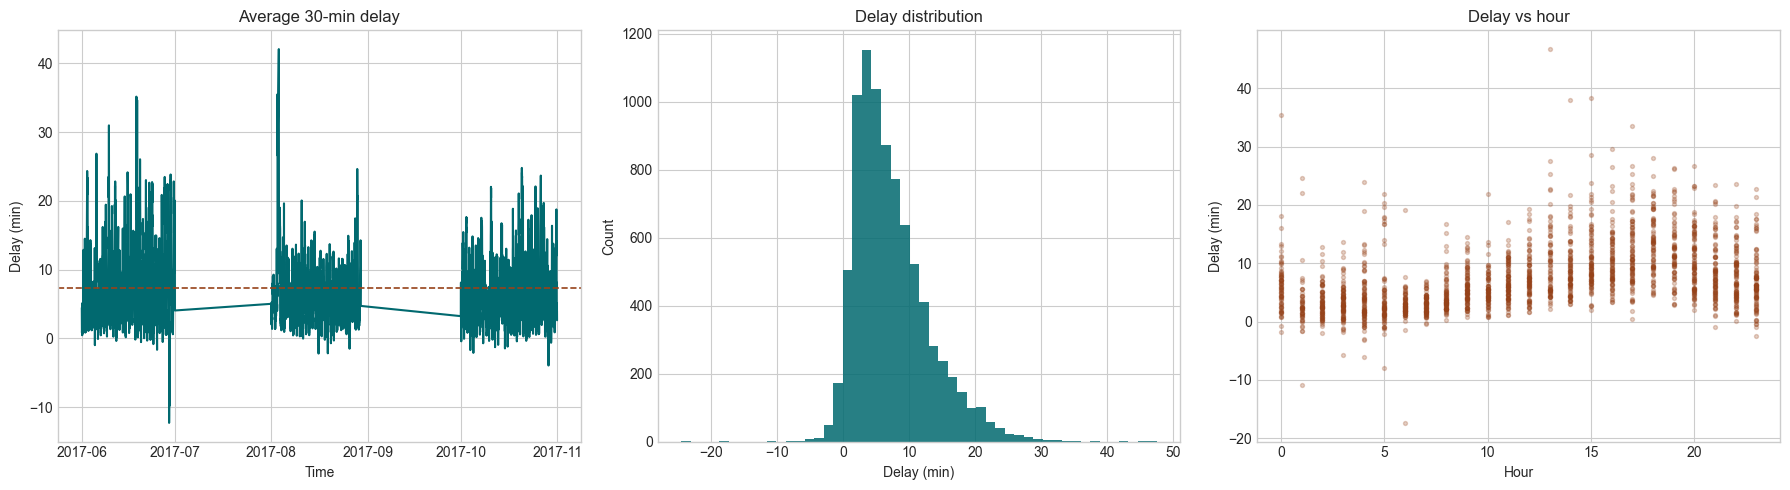

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ts = agg.set_index("bin30")["delay_minutes"].resample("30min").mean().dropna()
axes[0].plot(ts.index, ts.values, color="#01696f", lw=1.5)
axes[0].axhline(ts.mean(), color="#964219", ls="--", lw=1.2)
axes[0].set_title("Average 30-min delay")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Delay (min)")

axes[1].hist(agg["delay_minutes"], bins=50, color="#01696f", alpha=0.85)
axes[1].set_title("Delay distribution")
axes[1].set_xlabel("Delay (min)")
axes[1].set_ylabel("Count")

sample = agg.sample(min(2000, len(agg)), random_state=RANDOM_STATE)
axes[2].scatter(sample["hour"], sample["delay_minutes"], s=8, alpha=0.25, color="#964219")
axes[2].set_title("Delay vs hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Delay (min)")

plt.tight_layout()
plt.show()

In [83]:
train_df = agg[agg["bin30"].dt.month.isin(TRAIN_MONTH)].copy()
val_df = agg[agg["bin30"].dt.month == VAL_MONTH].copy()

print(f"Train rows: {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")

Train rows: 5,735
Validation rows: 2,673


In [84]:
formula = "delay_minutes ~ hour + dayofweek + isweekend + ispeak + OriginLat + OriginLong + DestinationLat + DestinationLong + stoplat + stoplon"

q10 = smf.quantreg(formula, train_df).fit(q=0.10)
q50 = smf.quantreg(formula, train_df).fit(q=0.50)
q90 = smf.quantreg(formula, train_df).fit(q=0.90)

print(q50.summary())

c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


                         QuantReg Regression Results                          
Dep. Variable:          delay_minutes   Pseudo R-squared:               0.1816
Model:                       QuantReg   Bandwidth:                       1.174
Method:                 Least Squares   Sparsity:                        10.31
Date:                Wed, 29 Apr 2026   No. Observations:                 5735
Time:                        13:14:53   Df Residuals:                     5724
                                        Df Model:                           10
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.8027   4194.142     -0.000      1.000   -8222.909    8221.304
hour                0.3777      0.010     36.012      0.000       0.357       0.398
dayofweek           0.3933      0.055      7.177      0.000       0.286       0.501
isweekend          -2.0446 

c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [85]:
val_pred = val_df.copy()
val_pred["lo"] = q10.predict(val_pred)
val_pred["md"] = q50.predict(val_pred)
val_pred["hi"] = q90.predict(val_pred)

val_pred["covered"] = (val_pred["delay_minutes"] >= val_pred["lo"]) & (val_pred["delay_minutes"] <= val_pred["hi"])

hour_cov = (
    val_pred.groupby("hour")["covered"]
    .mean()
    .reset_index(name="coverage")
    .sort_values("hour")
)

display(hour_cov)

,hour,coverage
0,0,0.660194
1,1,0.759494
2,2,0.879630
3,3,0.824074
4,4,0.814815
5,5,0.794643
6,6,0.883929
7,7,0.642857
8,8,0.794643
9,9,0.803571


In [86]:
problem_hours = hour_cov.loc[
    (hour_cov["coverage"] < 0.75) | (hour_cov["coverage"] > 0.85),
    "hour"
].tolist()

print("Problem hours:", problem_hours)

hour_models = {}
for h in problem_hours:
    h_train = train_df[train_df["hour"] == h].copy()
    if len(h_train) >= 20:
        hour_models[h] = {
            "q10": smf.quantreg(formula, h_train).fit(q=0.10),
            "q50": smf.quantreg(formula, h_train).fit(q=0.50),
            "q90": smf.quantreg(formula, h_train).fit(q=0.90),
        }

print(f"Fallback models fitted: {len(hour_models)}")

Problem hours: [0, 2, 6, 7, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number

Fallback models fitted: 14


c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [87]:
ridge_df = pd.read_csv("predictions_ridge_test.csv")
ridge_df["timestamp"] = pd.to_datetime(ridge_df["timestamp"], errors="coerce")

ridge_df = ridge_df.dropna(subset=["timestamp", "horizon", "horizon_min", "y_true", "y_pred", "residual"]).copy()

ridge_df["bin30"] = ridge_df["timestamp"].dt.floor("30min")
ridge_df["hour"] = ridge_df["timestamp"].dt.hour
ridge_df["dayofweek"] = ridge_df["timestamp"].dt.dayofweek
ridge_df["isweekend"] = (ridge_df["dayofweek"] >= 5).astype(int)
ridge_df["ispeak"] = ((ridge_df["hour"].between(7, 9)) | (ridge_df["hour"].between(16, 19))).astype(int)

print(f"December rows: {len(ridge_df):,}")
display(ridge_df.head())

December rows: 16,836


,timestamp,horizon,horizon_min,y_true,y_pred,residual,bin30,hour,dayofweek,isweekend,ispeak
0,2017-12-02 00:00:00,1,30,5.5280,7.6419,-2.1139,2017-12-02 00:00:00,0,5,1,0
1,2017-12-02 00:30:00,1,30,4.4315,4.9204,-0.4889,2017-12-02 00:30:00,0,5,1,0
2,2017-12-02 01:00:00,1,30,2.8500,4.4899,-1.6399,2017-12-02 01:00:00,1,5,1,0
3,2017-12-02 01:30:00,1,30,1.4241,2.5432,-1.1191,2017-12-02 01:30:00,1,5,1,0
4,2017-12-02 02:00:00,1,30,1.3431,1.5164,-0.1733,2017-12-02 02:00:00,2,5,1,0


In [88]:
# Use only predictors that also exist in ridge_df
test_formula = "hour + dayofweek + isweekend + ispeak"

q10_test = smf.quantreg(f"residual ~ {test_formula}", ridge_df).fit(q=0.10)
q50_test = smf.quantreg(f"residual ~ {test_formula}", ridge_df).fit(q=0.50)
q90_test = smf.quantreg(f"residual ~ {test_formula}", ridge_df).fit(q=0.90)

test_pred = ridge_df.copy()
test_pred["r_lo"] = q10_test.predict(test_pred)
test_pred["r_md"] = q50_test.predict(test_pred)
test_pred["r_hi"] = q90_test.predict(test_pred)

test_pred["lo"] = test_pred["y_pred"] + test_pred["r_lo"]
test_pred["md"] = test_pred["y_pred"] + test_pred["r_md"]
test_pred["hi"] = test_pred["y_pred"] + test_pred["r_hi"]

In [89]:
def mae(y, yhat):
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

y = test_pred["y_true"]

results = pd.DataFrame([
    {
        "model": "Ridge baseline",
        "MAE": mae(y, test_pred["y_pred"]),
        "RMSE": rmse(y, test_pred["y_pred"]),
        "Coverage": np.nan,
        "Avg interval width": np.nan
    },
    {
        "model": "Ridge + QR median",
        "MAE": mae(y, test_pred["md"]),
        "RMSE": rmse(y, test_pred["md"]),
        "Coverage": np.nan,
        "Avg interval width": np.nan
    },
    {
        "model": "Ridge + QR interval",
        "MAE": mae(y, test_pred["md"]),
        "RMSE": rmse(y, test_pred["md"]),
        "Coverage": np.mean((y >= test_pred["lo"]) & (y <= test_pred["hi"])),
        "Avg interval width": np.mean(test_pred["hi"] - test_pred["lo"])
    }
])

display(results.round(3))

,model,MAE,RMSE,Coverage,Avg interval width
0,Ridge baseline,3.221,4.589,NaN,NaN
1,Ridge + QR median,2.949,4.175,NaN,NaN
2,Ridge + QR interval,2.949,4.175,0.8,9.536


In [97]:
def mae(y, yhat):
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

y = test_pred["y_true"]

results = pd.DataFrame([
    {
        "model": "Ridge + QR interval",
        "MAE": mae(y, test_pred["md"]),
        "RMSE": rmse(y, test_pred["md"]),
        "Coverage": np.mean((y >= test_pred["lo"]) & (y <= test_pred["hi"])),
        "Avg interval width": np.mean(test_pred["hi"] - test_pred["lo"])
    }
])

display(results.round(3))

,model,MAE,RMSE,Coverage,Avg interval width
0,Ridge + QR interval,2.949,4.175,0.8,9.536


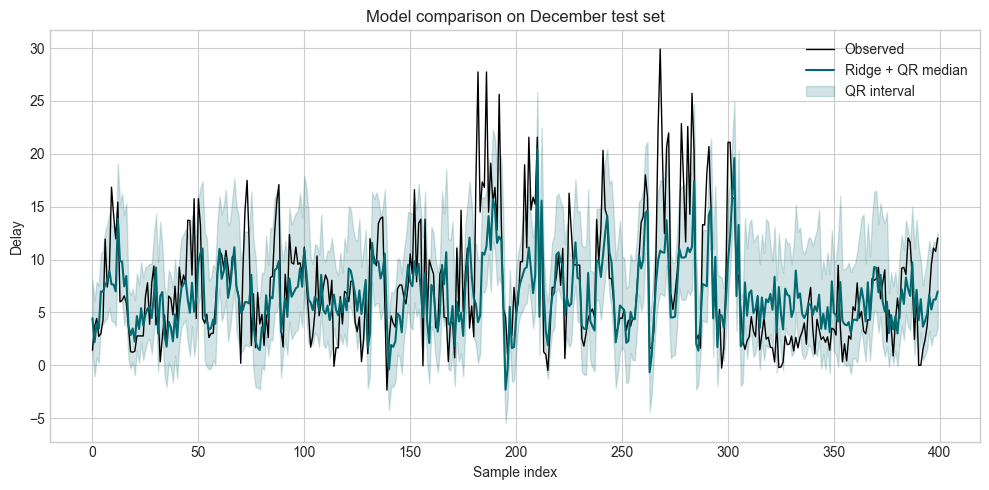

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))

s = test_pred.sample(min(400, len(test_pred)), random_state=RANDOM_STATE).sort_values("timestamp")
idx = np.arange(len(s))

ax.plot(idx, s["y_true"], color="black", lw=1, label="Observed")
ax.plot(idx, s["md"], color="#01696f", lw=1.5, label="Ridge + QR median")
ax.fill_between(idx, s["lo"], s["hi"], color="#01696f", alpha=0.18, label="QR interval")

ax.set_title("Model comparison on December test set")
ax.set_xlabel("Sample index")
ax.set_ylabel("Delay")
ax.legend()
plt.tight_layout()
plt.show()

In [100]:
bp_features = [
    "hour",
    "ispeak",
    "isweekend",
    "OriginLat",
    "OriginLong",
    "DestinationLat",
    "DestinationLong",
    "stoplat",
    "stoplon"
]

bp_df = train_df[["delay_minutes"] + bp_features].dropna().copy()

X_bp = sm.add_constant(bp_df[bp_features])
y_bp = bp_df["delay_minutes"]

ols_temp = sm.OLS(y_bp, X_bp).fit()
bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(ols_temp.resid, X_bp)

print(f"Breusch-Pagan LM statistic : {bp_lm:.3f}")
print(f"LM test p-value           : {bp_lm_pvalue:.6f}")
print(f"F statistic               : {bp_fvalue:.3f}")
print(f"F test p-value            : {bp_f_pvalue:.6f}")

if bp_lm_pvalue < 0.05:
    print("\n✓ HETEROSCEDASTICITY CONFIRMED (p < 0.05)")
    print("  Residual variance is not constant across observations.")
    print("  This supports using Quantile Regression instead of relying only on OLS.")
else:
    print("\nNo significant heteroscedasticity detected.")
    print("OLS may be adequate for constant-variance assumptions.")

Breusch-Pagan LM statistic : 126.583
LM test p-value           : 0.000000
F statistic               : 14.357
F test p-value            : 0.000000

✓ HETEROSCEDASTICITY CONFIRMED (p < 0.05)
  Residual variance is not constant across observations.
  This supports using Quantile Regression instead of relying only on OLS.


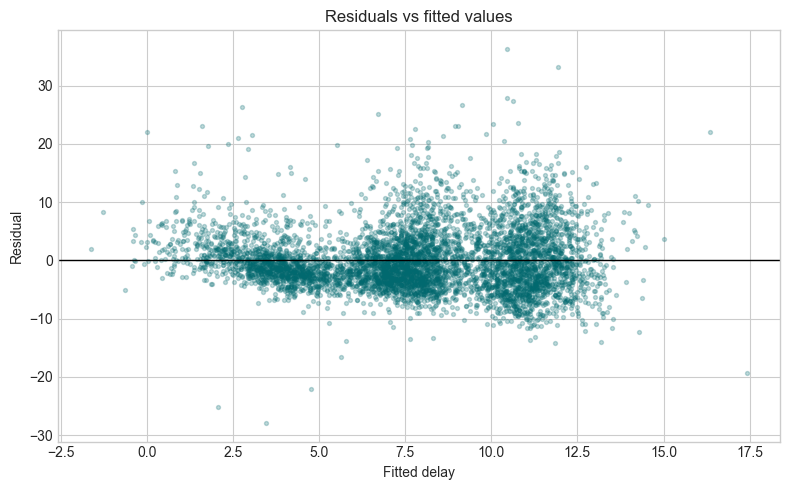

In [101]:
plt.figure(figsize=(8, 5))
plt.scatter(ols_temp.fittedvalues, ols_temp.resid, s=8, alpha=0.25, color="#01696f")
plt.axhline(0, color="black", lw=1)
plt.xlabel("Fitted delay")
plt.ylabel("Residual")
plt.title("Residuals vs fitted values")
plt.tight_layout()
plt.show()